# Assignment 2 — Biologically Inspired Optimization, Adversarial Search, and Game-Theoretic Decision Making

COMP3410/6410 2025 S2

**Weight**: 30% (30 marks)  
**Due**: 11:55pm Friday Week 11  
**Submission**: **This single Jupyter Notebook** (runs end-to-end). 

**Unit Learning Outcomes (assessed):**
- **ULO1**: Describe the roles of various search techniques in AI and use appropriate tools to implement them.
- **ULO3**: Explain biologically inspired algorithms and their roles in AI, and implement such algorithms in different contexts including adversarial games. 

**How to use this notebook**
> 1. Fill in the markdown cells for your answers of theory, analysis, reflection.
> 2. Implement your solutions (GA, ACO, adversarial search, one-shot/repeated games) in code cells.
> 3. Ensure the notebook is fully reproducible: `Kernel → Restart & Run All` should complete without errors and regenerate your results.
> 4. Replace all **TODO(you)** placeholders with your own work.
> 5. Fix a random seed (and state it) for comparability of plots/tables.
> 6. Keep everything self-contained (no external files or internet calls); include any small helper data you need inside the notebook.
> 7. Show key plots/tables (convergence curves, payoff matrices, trajectories) inline and briefly explain what each shows.
> 8. Use clear headings and short captions so your logic is easy to follow.

**Submission checklist**

- [ ] All required sections completed (markdown + code).
- [ ] Seeds set and documented; results reproducible with Run-All.
- [ ] Plots/tables included and labeled.
- [ ] No errors on a clean run; outputs visible.
- [ ] Academic integrity: all sources (if any) cited; work is your own.

# Student Information
- **Name**: _Mohammad Rakin Rayan_ 
- **Student ID**: _48658057_ 
- **Email**: _mohammadrakin.rayan@students.mq.edu.au_ 
---

# 0 Assignment Global Variables
## 0.1 Import Modules

In [1]:
# Reproducibility & basic imports
# TODO(you) add any into this cell that you may need
import random, math, statistics, itertools, functools, time
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Any, Optional
import numpy as np

# plotting
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import List, Tuple, Dict
import math

If you get a ModuleNotFoundError (e.g., No module named 'matplotlib')
- Use the next cell to install the missing package(s) into the current environment (e.g., pip install matplotlib).
- After it finishes, comment out the install line(s) to avoid re-installing every run (e.g., # pip install matplotlib).
- Return to the above imports cell and run it again (or use Kernel → Restart & Run All to be safe).

In [2]:
# pip install matplotlib

## 0.2 Reproducibility & Random Seeds — read me first

Your algorithms (GA, ACO, search sampling, etc.) use randomness. To make your results reproducible (so markers can rerun and get the same numbers/plots), we control the random generators with a seed.
- `GLOBAL_SEED` is the single source of truth for your notebook’s randomness.
- `random.seed(...)` and `np.random.seed(...)` initialise the Python and NumPy random number generators.
- `set_seed(seed)` is a helper you can call at the top of any experiment to lock in a specific seed and print it for the log.

**How you should use it (your TODO)**
- At the start of the notebook (or before an experiment block), call: `set_seed(42)  # TODO(you): choose a seed and keep it consistent for your main results`.
- When you run multiple experiments (e.g., sensitivity analysis), either:
  - keep the seed fixed to compare algorithmic changes fairly, or
  - vary seeds intentionally and report the list of seeds you used (e.g., 5 runs with seeds [1, 2, 3, 4, 5]) and show mean ± std.
  
**When to change the seed**
- Change the seed only when you **intend to sample a different random run**, e.g., to show robustness.
- For your **primary results** (tables/plots in the report), keep one seed so outputs are exactly reproducible.

In [3]:
# Set a global seed for reproducibility (you may change this but keep it logged)
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

def set_seed(seed:int=42):
    global GLOBAL_SEED
    GLOBAL_SEED = seed
    random.seed(seed)
    np.random.seed(seed)
    print(f"Seed set to {seed}")

# 1 Project Narrative

You work for a **drone delivery company** operating under battery and time-window constraints and competing with a rival fleet. This is a generalisation of the Traveling Salesman Problem (TSP), known as the **Capacitated Vehicle Routing Problem with Time Windows (CVRPTW)**. Unlike TSP, it involves constraints and multiple routes.

A drone delivery company must schedule operations each day:
- A fleet of drones must deliver packages to multiple locations.
- Each drone has a battery capacity limit (maximum distance it can travel before recharging).
- Each location has a time window when delivery is allowed (e.g., between 09:00–12:00).

This project is completed in three parts inside one notebook: 
1. **Biologically Inspired Optimization (GA & ACO)** for CVRPTW.
2. **Adversarial Search** (Negamax Plus $\alpha–\beta$ pruning) in competitive routing.
3. **Game-Theoretic Analysis** (payoff matrices, equilibria, repeated games). 

## 1.1 Dataset

This assignment uses one fixed dataset for the entire project. **Do not modify any values.**

- Depot parameters: number of drones, per-drone battery budget (distance units), travel speed, operating day horizon.
- Requests: coordinates `(x, y)`, time window `[tw_start, tw_end]` in minutes (from 00:00), service time, and demand (use 1 unless extending capacity).

**How to use the dataset**: Use `INSTANCE` everywhere for data in all parts (GA/ACO, adversarial search engine, payoff construction). If you need distances, use `euclid((x1,y1),(x2,y2))`.

In [4]:
# === OFFICIAL SINGLE DATASET (INLINE, DO NOT MODIFY) ==========================

@dataclass
class Request:
    id: int
    x: float
    y: float
    tw_start: float   # minutes from 00:00 (e.g., 540 = 09:00)
    tw_end: float
    service: float    # minutes
    demand: int       # use 1 if not modeling capacity beyond battery

@dataclass
class Instance:
    name: str
    depot: Tuple[float, float]
    drones: int
    battery: float
    speed: float
    day_start: float
    day_end: float
    requests: List[Request]

def build_instance(name: str, spec: Dict) -> Instance:
    d = spec["depot"]
    inst = Instance(
        name=name,
        depot=(float(d["x"]), float(d["y"])),
        drones=int(d["drones"]),
        battery=float(d["battery"]),
        speed=float(d["speed"]),
        day_start=float(d["day_start"]),
        day_end=float(d["day_end"]),
        requests=[
            Request(
                id=int(r["id"]),
                x=float(r["x"]), y=float(r["y"]),
                tw_start=float(r["tw_start"]), tw_end=float(r["tw_end"]),
                service=float(r["service"]), demand=int(r.get("demand", 1))
            ) for r in spec["requests"]
        ],
    )
    # Basic validation
    assert inst.drones > 0 and inst.battery > 0 and inst.speed > 0, f"{name}: invalid drones/battery/speed"
    assert inst.day_start < inst.day_end, f"{name}: invalid day horizon"
    ids = set()
    for q in inst.requests:
        assert q.id != 0, f"{name}: request id 0 reserved for depot"
        assert q.tw_start < q.tw_end, f"{name}: request {q.id} has invalid time window"
        assert q.id not in ids, f"{name}: duplicate request id {q.id}"
        ids.add(q.id)
    inst.requests.sort(key=lambda q: q.id)
    return inst

# Official single instance (20 requests)
OFFICIAL = {
    "depot": {
        "x": 50.0, "y": 50.0,
        "drones": 4, "battery": 100.0, "speed": 1.0,
        "day_start": 480.0,    # 08:00
        "day_end": 1140.0,     # 19:00
    },
    "requests": [
        # north-west cluster
        {"id": 1,  "x": 20.0, "y": 82.0, "tw_start": 540.0, "tw_end": 660.0, "service": 6.0, "demand": 1},
        {"id": 2,  "x": 28.0, "y": 76.0, "tw_start": 585.0, "tw_end": 720.0, "service": 6.0, "demand": 1},
        {"id": 3,  "x": 34.0, "y": 70.0, "tw_start": 600.0, "tw_end": 690.0, "service": 6.0, "demand": 1},
        {"id": 4,  "x": 18.0, "y": 65.0, "tw_start": 560.0, "tw_end": 660.0, "service": 6.0, "demand": 1},
        {"id": 5,  "x": 26.0, "y": 58.0, "tw_start": 630.0, "tw_end": 750.0, "service": 6.0, "demand": 1},

        # north-east cluster
        {"id": 6,  "x": 72.0, "y": 82.0, "tw_start": 570.0, "tw_end": 660.0, "service": 6.0, "demand": 1},
        {"id": 7,  "x": 80.0, "y": 76.0, "tw_start": 600.0, "tw_end": 720.0, "service": 6.0, "demand": 1},
        {"id": 8,  "x": 66.0, "y": 70.0, "tw_start": 585.0, "tw_end": 690.0, "service": 6.0, "demand": 1},
        {"id": 9,  "x": 78.0, "y": 64.0, "tw_start": 615.0, "tw_end": 735.0, "service": 6.0, "demand": 1},
        {"id": 10, "x": 70.0, "y": 60.0, "tw_start": 540.0, "tw_end": 630.0, "service": 6.0, "demand": 1},

        # south-east cluster
        {"id": 11, "x": 78.0, "y": 40.0, "tw_start": 660.0, "tw_end": 780.0, "service": 6.0, "demand": 1},
        {"id": 12, "x": 72.0, "y": 28.0, "tw_start": 600.0, "tw_end": 720.0, "service": 6.0, "demand": 1},
        {"id": 13, "x": 66.0, "y": 22.0, "tw_start": 585.0, "tw_end": 690.0, "service": 6.0, "demand": 1},
        {"id": 14, "x": 62.0, "y": 34.0, "tw_start": 540.0, "tw_end": 630.0, "service": 6.0, "demand": 1},
        {"id": 15, "x": 70.0, "y": 18.0, "tw_start": 690.0, "tw_end": 810.0, "service": 6.0, "demand": 1},

        # south-west cluster
        {"id": 16, "x": 30.0, "y": 24.0, "tw_start": 600.0, "tw_end": 720.0, "service": 6.0, "demand": 1},
        {"id": 17, "x": 24.0, "y": 18.0, "tw_start": 585.0, "tw_end": 690.0, "service": 6.0, "demand": 1},
        {"id": 18, "x": 36.0, "y": 16.0, "tw_start": 660.0, "tw_end": 780.0, "service": 6.0, "demand": 1},
        {"id": 19, "x": 40.0, "y": 32.0, "tw_start": 540.0, "tw_end": 630.0, "service": 6.0, "demand": 1},
        {"id": 20, "x": 22.0, "y": 30.0, "tw_start": 615.0, "tw_end": 735.0, "service": 6.0, "demand": 1},
    ],
}

INSTANCE = build_instance("Main", OFFICIAL)

# convenience helpers
def euclid(a: Tuple[float,float], b: Tuple[float,float]) -> float:
    return math.hypot(a[0]-b[0], a[1]-b[1])

print(f"Loaded INSTANCE '{INSTANCE.name}': "
      f"requests={len(INSTANCE.requests)}, drones={INSTANCE.drones}, battery={INSTANCE.battery}, "
      f"horizon=({INSTANCE.day_start},{INSTANCE.day_end})")
assert len(INSTANCE.requests) == 20, "INSTANCE must have 20 requests"

Loaded INSTANCE 'Main': requests=20, drones=4, battery=100.0, horizon=(480.0,1140.0)


## 1.2 Metrics & Payoff (read first, then implement)

You’ll define a single source of truth for evaluation so the same logic is reused across GA/ACO, adversarial search, game-theory payoff tables.

**What you must measure (routing metrics)**
- **Total distance**: Sum of Euclidean travel for each drone route (including depot → first and last → depot).
- **Energy cost**: Distance × `ENERGY_PER_UNIT` (constant you define).
- On-time services vs late services:
    - Each served request has an **arrival time** (minutes from day start).
    - A service is **on time** if `arrival_time ≤ tw_end`. It may wait if arriving before `tw_start` (waiting is allowed and costs time, not distance).
    - A service is **late** if `arrival_time > tw_end` (discouraged; see penalties).
- **Unserved requests**: Requests that never appear in any drone’s route.
- Constraint violations (if you treat constraints as “hard”):
    - **Battery**: Total route distance per drone must be `≤ INSTANCE.battery`.
    - **Day horizon**: A drone must finish before `INSTANCE.day_end` (and not depart before `INSTANCE.day_start`).
    - **Time windows**: Decide your policy:
        - _Hard_: disallow late services; routes causing lateness are invalid.
        - _Soft_: allow lateness but penalise it (preferred for graded comparability).
- Makespan / total time (optional, but useful for analysis): The latest finish time across drones.

- **Payoff (used for game analysis)**: `revenue−energy_cost−late_penalties−unserved_penalties−violation_penalties (if any)`. 
    - **Revenue**: e.g., `REVENUE_PER_SERVICE × (# of served requests)` (Optionally weight by zones or time-of-day, but keep it linear.)
    - **Energy cost**: `ENERGY_PER_UNIT × total_distance`
    - **Late penalties** (soft windows): e.g., `LATE_PENALTY_PER_MIN × total_late_minutes`
    - **Unserved penalties**: e.g., `UNSERVED_PENALTY_PER_REQ × (# unserved)`
    - **Violation penalties** (if you permit “invalid” routes to return a finite score): very large constants to dominate the objective, or simply reject invalid routes and return `-inf`.
    
Edge-cases you must handle:
- Empty route for a drone (allowed).
- Multiple drones may visit the same request only if you count it once; simplest is: disallow duplicates across all routes.
- If you treat time windows as hard: a single late service invalidates the route (or entire solution) — be explicit.

Tip: Keep your definitions consistent across all parts. Keep the payoff linear/transparent. Avoid nonlinear squashes (e.g., tanh) because they break expectation properties you’ll rely on in adversarial search, game theory.

TODO(you) 

Reporting expectations (what to show in your notebook)

- A short table for your chosen constants.
- One example evaluation call showing the full metrics dict for a simple 2–3 route solution.
- A 2–3 sentence justification for soft vs hard time-window choice and battery policy.
- Confirm that the same evaluator is used in Part 1 (GA/ACO fitness), Part 2 (adversarial search), and Part 3 (payoff matrices).

In [6]:
# 1.2 Metrics & Payoff

# Tunable constants (single source of truth used everywhere)
REVENUE_PER_SERVICE      = 10.0
ENERGY_PER_UNIT          = 1.0          # cost per distance unit
LATE_PENALTY_PER_MIN     = 0.5          # soft time-window penalty per minute late
UNSERVED_PENALTY_PER_REQ = 15.0
VIOLATION_PENALTY        = 10_000.0     # large penalty for constraint violations

# internal cache for quick lookup
_REQ_BY_ID = {r.id: r for r in INSTANCE.requests}
_ALL_REQ_IDS = set(_REQ_BY_ID.keys())

def route_distance(route_ids, inst: Instance) -> float:
    """Euclidean distance including depot->first and last->depot."""
    if not route_ids:
        # drone stays at depot
        return 0.0
    dep = inst.depot
    dist = 0.0
    cur = dep
    for rid in route_ids:
        r = _REQ_BY_ID[rid]
        nxt = (r.x, r.y)
        dist += euclid(cur, nxt)
        cur = nxt
    # return to depot
    dist += euclid(cur, dep)
    return dist

def simulate_route_timing(route_ids, inst: Instance):
    """
    Simulate one drone's day:
      - starts at inst.day_start from depot
      - travels at inst.speed (distance units per minute)
      - can wait if early; late minutes penalised but allowed (soft windows)
      - returns detailed timing and violation flags (battery/day horizon)
    """
    # start state
    t = inst.day_start
    pos = inst.depot
    total_dist = 0.0
    total_late_min = 0.0
    on_time, late = 0, 0

    arrival_times = []
    service_starts = []
    departures = []

    for rid in route_ids:
        r = _REQ_BY_ID[rid]
        travel = euclid(pos, (r.x, r.y))
        total_dist += travel
        arrival = t + (travel / inst.speed)
        arrival_times.append(arrival)

        # soft windows: waiting allowed, late penalised
        wait = max(0.0, r.tw_start - arrival)
        late_min = max(0.0, arrival - r.tw_end)
        total_late_min += late_min

        if late_min > 0:
            late += 1
        else:
            on_time += 1

        start_service = arrival + wait
        service_starts.append(start_service)
        depart = start_service + r.service
        departures.append(depart)

        # update state
        t = depart
        pos = (r.x, r.y)

    # go back to depot
    back = euclid(pos, inst.depot) if route_ids else 0.0
    total_dist += back
    finish_time = t + (back / inst.speed)

    # constraint checks (battery & day horizon treated as "hard" via penalty)
    battery_violation = (total_dist > inst.battery)
    day_violation = (finish_time > inst.day_end)

    return {
        "distance": total_dist,
        "finish_time": finish_time,
        "late_minutes": total_late_min,
        "on_time": on_time,
        "late": late,
        "arrival_times": arrival_times,
        "service_starts": service_starts,
        "departures": departures,
        "battery_violation": battery_violation,
        "day_violation": day_violation,
    }

def evaluate_solution(routes, inst: Instance):
    """
    Primary evaluator used across GA/ACO (fitness), adversarial search,
    and game-theoretic payoffs.

    routes: List[List[int]] where each inner list is the sequence of request IDs
            visited by one drone. Empty lists allowed.
    Policy:
      - Time windows: SOFT (penalise late minutes; allow waiting).
      - Battery & day horizon: HARD via large penalties (VIOLATION_PENALTY).
      - No duplicates across drones (duplicates flagged & penalised).
      - Unserved requests are penalised (UNSERVED_PENALTY_PER_REQ).
    """
    # duplicates & coverage 
    seen = []
    duplicate_ids = set()
    for r in routes:
        for rid in r:
            if rid in seen:
                duplicate_ids.add(rid)
            else:
                seen.append(rid)
    seen_set = set(seen)
    # filter to only valid request IDs found in INSTANCE
    served_ids = seen_set & _ALL_REQ_IDS
    invalid_ids = seen_set - _ALL_REQ_IDS  # shouldn't happen if you pass correct IDs

    unserved_ids = _ALL_REQ_IDS - served_ids

    # per-route simulation
    per_route = []
    total_dist = 0.0
    total_late_min = 0.0
    makespan = INSTANCE.day_start
    violations = 0

    for r in routes:
        sim = simulate_route_timing(r, inst)
        per_route.append(sim)
        total_dist += sim["distance"]
        total_late_min += sim["late_minutes"]
        makespan = max(makespan, sim["finish_time"])
        if sim["battery_violation"]:
            violations += 1
        if sim["day_violation"]:
            violations += 1

    # extras: duplicates and invalid IDs count as violations
    violations += len(duplicate_ids) + len(invalid_ids)

    # economics 
    served_count = len(served_ids)  # count each served request once
    revenue = REVENUE_PER_SERVICE * served_count
    energy_cost = ENERGY_PER_UNIT * total_dist
    late_penalty = LATE_PENALTY_PER_MIN * total_late_min
    unserved_penalty = UNSERVED_PENALTY_PER_REQ * len(unserved_ids)
    violation_penalty = VIOLATION_PENALTY * violations

    payoff = revenue - energy_cost - late_penalty - unserved_penalty - violation_penalty

    metrics = {
        "routes": routes,
        "per_route": per_route,
        "served_count": served_count,
        "unserved_count": len(unserved_ids),
        "unserved_ids": sorted(list(unserved_ids)),
        "duplicate_ids": sorted(list(duplicate_ids)),
        "invalid_ids": sorted(list(invalid_ids)),
        "total_distance": total_dist,
        "energy_cost": energy_cost,
        "total_late_minutes": total_late_min,
        "revenue": revenue,
        "late_penalty": late_penalty,
        "unserved_penalty": unserved_penalty,
        "violation_penalty": violation_penalty,
        "violations_count": violations,
        "makespan": makespan,
        "payoff": payoff,
        "valid": (violations == 0),
        "constants": {
            "REVENUE_PER_SERVICE": REVENUE_PER_SERVICE,
            "ENERGY_PER_UNIT": ENERGY_PER_UNIT,
            "LATE_PENALTY_PER_MIN": LATE_PENALTY_PER_MIN,
            "UNSERVED_PENALTY_PER_REQ": UNSERVED_PENALTY_PER_REQ,
            "VIOLATION_PENALTY": VIOLATION_PENALTY,
        }
    }
    return metrics

def print_constants_table():
    """Small readable table (no external deps)."""
    kv = [
        ("REVENUE_PER_SERVICE",      REVENUE_PER_SERVICE,      "revenue per completed delivery"),
        ("ENERGY_PER_UNIT",          ENERGY_PER_UNIT,          "cost per distance unit"),
        ("LATE_PENALTY_PER_MIN",     LATE_PENALTY_PER_MIN,     "penalty per minute late"),
        ("UNSERVED_PENALTY_PER_REQ", UNSERVED_PENALTY_PER_REQ, "penalty per unserved request"),
        ("VIOLATION_PENALTY",        VIOLATION_PENALTY,        "battery/day/duplicate violations"),
    ]
    print("Evaluator Constants")
    print(f"{'Name':28} | {'Value':>10} | Description")
    print("-"*70)
    for name, val, desc in kv:
        print(f"{name:28} | {val:10} | {desc}")

# Example Call 
# A simple 4-route plan grouped by quadrants; empty routes are allowed.
example_solution = [
    [1, 2, 3, 4, 5],           # NW cluster
    [6, 7, 8, 9, 10],          # NE cluster
    [11, 12, 13, 14, 15],      # SE cluster
    [16, 17, 18, 19, 20],      # SW cluster
]

print_constants_table()
ex_metrics = evaluate_solution(example_solution, INSTANCE)
print("\n Example evaluation (full metrics dict)")
for k, v in ex_metrics.items():
    if k == "per_route":
        # keep output compact but informative
        print(f"{k}:")
        for i, pr in enumerate(v):
            print(f"  route {i}: "
                  f"dist={pr['distance']:.2f}, finish={pr['finish_time']:.1f}, "
                  f"late_min={pr['late_minutes']:.1f}, "
                  f"battery_violation={pr['battery_violation']}, day_violation={pr['day_violation']}")
    else:
        print(f"{k}: {v}")

Evaluator Constants
Name                         |      Value | Description
----------------------------------------------------------------------
REVENUE_PER_SERVICE          |       10.0 | revenue per completed delivery
ENERGY_PER_UNIT              |        1.0 | cost per distance unit
LATE_PENALTY_PER_MIN         |        0.5 | penalty per minute late
UNSERVED_PENALTY_PER_REQ     |       15.0 | penalty per unserved request
VIOLATION_PENALTY            |    10000.0 | battery/day/duplicate violations

 Example evaluation (full metrics dict)
routes: [[1, 2, 3, 4, 5], [6, 7, 8, 9, 10], [11, 12, 13, 14, 15], [16, 17, 18, 19, 20]]
per_route:
  route 0: dist=115.04, finish=670.7, late_min=0.0, battery_violation=True, day_violation=False
  route 1: dist=108.79, finish=684.0, late_min=25.6, battery_violation=True, day_violation=False
  route 2: dist=119.91, finish=780.2, late_min=86.5, battery_violation=True, day_violation=False
  route 3: dist=122.47, finish=747.0, late_min=52.5, battery_vi

### Evaluator Constants

| **Name** | **Value** | **Description** |
|:----------------------------|:----------:|:----------------------------------------------|
| `REVENUE_PER_SERVICE` | **10.0** | Revenue per completed delivery |
| `ENERGY_PER_UNIT` | **1.0** | Cost per distance unit |
| `LATE_PENALTY_PER_MIN` | **0.5** | Penalty per minute late |
| `UNSERVED_PENALTY_PER_REQ` | **15.0** | Penalty per unserved request |
| `VIOLATION_PENALTY` | **10,000.0** | Penalty for battery/day/duplicate violations |


### Justification: Time-Window and Battery Policy

I use **soft time windows** so slightly late arrivals are scored with a proportional penalty rather than discarded. This keeps the objective **continuous and comparable**, which helps GA/ACO/adversarial search learn from partially feasible schedules. In contrast, **battery capacity and day-horizon** are enforced as **hard constraints** via a large violation penalty to keep solutions physically realistic while still returning a finite payoff for analysis.


# 2 Part 1-Biologically Inspired Optimisation (GA & ACO) 

You must design, implement, and evaluate biologically inspired algorithms from Genetic Algorithms (GA) and Ant Colony Optimization (ACO) to solve the CVRPTW scheduling problem.

**Theoretical Design (Critical Thinking)** (Report)
1. Explain how this problem differs from the classical TSP, and why standard binary encoding is unsuitable.
2. Propose how you will adapt GA to solve this problem:
    - Candidate representation (permutation or alternative).
    - Crossover and mutation operators.
    - Fitness function design (must account for distance + battery + time windows).
3. Propose how you will adapt ACO to solve this problem:
    - Pheromone representation.
    - Visibility ($\eta$) and how it incorporates both distance and time feasibility.
    - Evaporation rules.
4. Critically discuss trade-offs between GA and ACO for this problem (exploration, exploitation, scalability).

**Implementation (Python Project)** (Code)
1. Implement Genetic Algorithm (GA):
    - Representation: routes assigned to drones (permutation or multi-route encoding).
    - Variation: ordered crossover, plus mutation adapted for multi-route constraints.
    - Fitness: penalise infeasible solutions (exceeding battery/time windows).
2. Implement Ant Colony Optimization (ACO):
    - Transition probability formula based on pheromone + visibility.
    - Pheromone update with evaporation and deposit.
    - Ensure feasible route construction under constraints.
3. Apply your implementations on provided dataset and with pre-defined metrics.

**Experimental Study (Analysis)** (Code + Report)
1. Report best and average performance for each algorithm on the dataset.
2. Present convergence behaviour (fitness vs generation/iteration).
3. Perform parameter sensitivity analysis:
    - For GA: vary population size or mutation rate.
    - For ACO: vary $\alpha$, $\beta$, and evaporation rate $\rho$.
4. Discuss how design choices affected performance, linking results to your theoretical expectations.

**Reflection (Critical Evaluation)** (Report)
1. Which algorithm performed better, and why?
2. Did your theoretical expectations (Part 1) match experimental results? Why or why not?
3. Propose one novel extension (e.g., hybrid GA–ACO, adaptive mutation/evaporation) and explain how it could improve performance for large-scale problems (>1000 locations).
4. Reflect on the strengths and weaknesses of your implementations.

_Report length: approximately 800 words (total for 2.1, 2.2, 2.3 and 2.4). There is no length limit for code._

## 2.1 Theoretical Design

### How CVRPTW differs from TSP and why binary encoding doesn’t work

The classical TSP uses one vehicle and has no time or capacity limits. The aim is simply to visit all nodes once and return using the shortest path.  
CVRPTW is harder because it has multiple drones, each with limited battery and time windows for each delivery. Many permutations become invalid as they can violate time or distance limits.  
Binary encoding (0/1 city selection) doesn’t fit this problem since it can’t ensure each request is visited exactly once or that routes are divided correctly across drones. It also loses the visit order, which is vital for timing.  
A permutation-based encoding with a decoder that splits deliveries into routes is therefore more suitable.

### Genetic Algorithm (GA) design

**Representation:**  
Each chromosome is a permutation of delivery IDs (1–20). A decoder splits this sequence into drone routes by inserting requests where they cause the smallest extra cost (distance + lateness). If all options break battery limits, the least bad one is chosen and penalised later by the evaluator.

**Variation operators:**  
- **Crossover:** Ordered Crossover (OX) keeps visit order and avoids duplicates.  
- **Mutation:** Randomly swaps two positions, and sometimes applies a small 2-opt reversal. The decoder rebuilds the routes every time.

**Fitness function:**  
Uses the same evaluator from §1.2.  
Fitness = revenue − energy − late − unserved − violation penalties.  
We maximise this value. Battery and day limits act as hard constraints through large penalties, while lateness is penalised softly per minute.

### Ant Colony Optimization (ACO) design

**Construction graph & pheromone:**  
Each pair of delivery nodes is connected. Pheromone τ[i,j] stores how good it is to visit j after i. Ants build a permutation, and the decoder later splits it into routes.

**Visibility (heuristic η):**  
For a partial path ending at i,  
h(i,j) = distance(i,j) + max(0, arrival_time − tw_end_j),  
then η(i,j) = 1 / (ε + h(i,j)).  
This favours closer and time-feasible moves; late arrivals lower visibility.

**Transition rule:**  
P(i→j) ∝ [τ(i,j)]^α × [η(i,j)]^β  
α controls pheromone exploitation; β controls heuristic strength.

**Evaporation & deposit:**  
After each iteration, pheromone evaporates (τ ← (1−ρ)τ).  
The best ant deposits extra pheromone based on its payoff, while poor or infeasible paths add almost nothing.

**Feasibility:**  
Each permutation is decoded and scored using the same §1.2 evaluator to ensure consistency.

### Trade-offs between GA and ACO

**Exploration:** GA explores broadly through crossover and mutation, while ACO relies on pheromone randomness.  
**Exploitation:** GA reuses good subsequences; ACO reinforces strong edges, which can cause early convergence.  
**Scalability:** GA is lighter on memory since it stores only a population, while ACO needs an O(n²) pheromone matrix.  
**Feasibility:** ACO naturally accounts for time windows through η; GA enforces them indirectly via selection pressure.

## 2.2 Implementation (Python Project)

In [7]:
# Decoder: permutation -> multi-route (greedy insertion with feasibility awareness)
set_seed(42)

def decode_permutation_to_routes(perm, inst: Instance):
    routes = [[] for _ in range(inst.drones)]
    sim_cache = [simulate_route_timing([], inst) for _ in range(inst.drones)]

    for rid in perm:
        best_idx, best_score, best_route = None, float("inf"), None
        for d in range(inst.drones):
            trial = routes[d] + [rid]
            before = sim_cache[d]
            after  = simulate_route_timing(trial, inst)
            # incremental score: distance + weighted lateness; discourage new violations
            inc = (after["distance"] - before["distance"]) \
                + LATE_PENALTY_PER_MIN * (after["late_minutes"] - before["late_minutes"])
            if (not before["battery_violation"]) and after["battery_violation"]:
                inc += 1000.0
            if inc < best_score:
                best_idx, best_score, best_route = d, inc, trial
        routes[best_idx] = best_route
        sim_cache[best_idx] = simulate_route_timing(best_route, inst)
    return routes

# Genetic Algorithm (permutation GA + decoder + §1.2 evaluator)

def ox_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(np.random.choice(n, 2, replace=False))
    child = [None]*n
    child[a:b+1] = p1[a:b+1]
    fill = [g for g in p2 if g not in child]
    j = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[j]; j += 1
    return child

def mutate_swap_2opt(perm, pm=0.2):
    p = perm[:]
    if np.random.rand() < pm:
        i, j = np.random.choice(len(p), 2, replace=False)
        p[i], p[j] = p[j], p[i]
    if np.random.rand() < 0.1:
        i, j = sorted(np.random.choice(len(p), 2, replace=False))
        p[i:j+1] = reversed(p[i:j+1])
    return p

def tournament_select(pop, fits, k=3):
    idxs = np.random.choice(len(pop), k, replace=False)
    best = max(idxs, key=lambda i: fits[i])
    return pop[best][:]

def run_ga(inst: Instance, pop_size=40, gens=60, pm=0.2, elite=2, seed=42):
    set_seed(seed)
    ids = [r.id for r in inst.requests]
    pop = [np.random.permutation(ids).tolist() for _ in range(pop_size)]

    def fit_of_perm(perm):
        routes = decode_permutation_to_routes(perm, inst)
        return evaluate_solution(routes, inst)

    mets = [fit_of_perm(p) for p in pop]
    fits = [m["payoff"] for m in mets]
    best_i = int(np.argmax(fits))
    best_perm = pop[best_i][:]
    best_metrics = mets[best_i]
    history = [best_metrics["payoff"]]

    for g in range(gens):
        # elitism
        new_pop = [pop[i][:] for i in np.argsort(fits)[-elite:]]
        # offspring
        while len(new_pop) < pop_size:
            p1 = tournament_select(pop, fits)
            p2 = tournament_select(pop, fits)
            c  = mutate_swap_2opt(ox_crossover(p1, p2), pm=pm)
            new_pop.append(c)
        pop = new_pop
        mets = [fit_of_perm(p) for p in pop]
        fits = [m["payoff"] for m in mets]
        cur_i = int(np.argmax(fits))
        if fits[cur_i] > best_metrics["payoff"]:
            best_perm = pop[cur_i][:]
            best_metrics = mets[cur_i]
        history.append(best_metrics["payoff"])

    best_routes = decode_permutation_to_routes(best_perm, inst)
    return {"best_routes": best_routes, "best_metrics": best_metrics, "history": history}

# Ant Colony Optimization (pheromone + visibility + decoder + §1.2 evaluator)

def run_aco(inst: Instance, ants=25, iters=60, alpha=1.0, beta=3.0, rho=0.2, Q=1.0, seed=42):
    set_seed(seed)
    ids = [r.id for r in inst.requests]
    n = len(ids)
    id_to_idx = {rid: i for i, rid in enumerate(ids)}
    tau = np.full((n, n), 1.0)  # pheromone

    def eta(cur_pos, cur_time, j):
        rj = _REQ_BY_ID[j]
        d = euclid(cur_pos, (rj.x, rj.y))
        arr = cur_time + d / INSTANCE.speed
        late = max(0.0, arr - rj.tw_end)
        h = d + late
        return 1.0 / (1e-9 + h)

    best = {"payoff": -1e18}
    best_perm, best_routes = None, None
    history = []

    for it in range(iters):
        # evaporation
        tau *= (1.0 - rho)
        tau = np.clip(tau, 1e-6, 1e6)

        iter_best = {"payoff": -1e18}
        perms = []

        for k in range(ants):
            remaining = set(ids)
            cur = np.random.choice(list(remaining))
            perm = [cur]; remaining.remove(cur)

            # lightweight sim state for heuristic
            pos = (_REQ_BY_ID[cur].x, _REQ_BY_ID[cur].y)
            t   = INSTANCE.day_start + euclid(INSTANCE.depot, pos)/INSTANCE.speed + _REQ_BY_ID[cur].service

            while remaining:
                cand = list(remaining)
                numer = []
                for j in cand:
                    a = tau[id_to_idx[cur], id_to_idx[j]] ** alpha
                    b = eta(pos, t, j) ** beta
                    numer.append(a * b)
                probs = np.array(numer) + 1e-12
                probs /= probs.sum()
                nxt = np.random.choice(cand, p=probs)

                # move & update heuristic state
                perm.append(nxt); remaining.remove(nxt)
                rj = _REQ_BY_ID[nxt]
                travel = euclid(pos, (rj.x, rj.y))
                arr = t + travel / INSTANCE.speed
                wait = max(0.0, rj.tw_start - arr)
                t = arr + wait + rj.service
                pos = (rj.x, rj.y)
                cur = nxt

            perms.append(perm)

        # deposit
        for perm in perms:
            routes = decode_permutation_to_routes(perm, inst)
            m = evaluate_solution(routes, inst)
            score = max(0.0, m["payoff"] - (-50000.0))  # shift so deposit >= 0
            if score > 0:
                for a, b in zip(perm[:-1], perm[1:]):
                    tau[id_to_idx[a], id_to_idx[b]] += Q * (score / 50000.0)

            if m["payoff"] > iter_best["payoff"]:
                iter_best = m
            if m["payoff"] > best["payoff"]:
                best, best_perm, best_routes = m, perm, routes

        history.append(best["payoff"])

    return {"best_routes": best_routes, "best_metrics": best, "history": history}
# Application of GA & ACO to INSTANCE and print brief metrics

ga_res  = run_ga(INSTANCE, pop_size=40, gens=60, pm=0.2, elite=2)
aco_res = run_aco(INSTANCE, ants=25, iters=60, alpha=1.0, beta=3.0, rho=0.2, Q=1.0)

def brief(m):
    print(f"served={m['served_count']}, unserved={m['unserved_count']}, "
          f"dist={m['total_distance']:.1f}, late_min={m['total_late_minutes']:.1f}, "
          f"violations={m['violations_count']}, valid={m['valid']}, payoff={m['payoff']:.1f}")

print("GA — best metrics:");  brief(ga_res["best_metrics"])
print("ACO — best metrics:"); brief(aco_res["best_metrics"])


Seed set to 42
Seed set to 42
Seed set to 42
GA — best metrics:
served=20, unserved=0, dist=452.6, late_min=62.0, violations=1, valid=False, payoff=-10283.6
ACO — best metrics:
served=20, unserved=0, dist=444.4, late_min=127.9, violations=1, valid=False, payoff=-10308.4


## 2.3 Experimental Study

Performance Summary
GA  -> Best: -10283.58,  Average: -10316.71
ACO -> Best: -10308.38,  Average: -10349.65


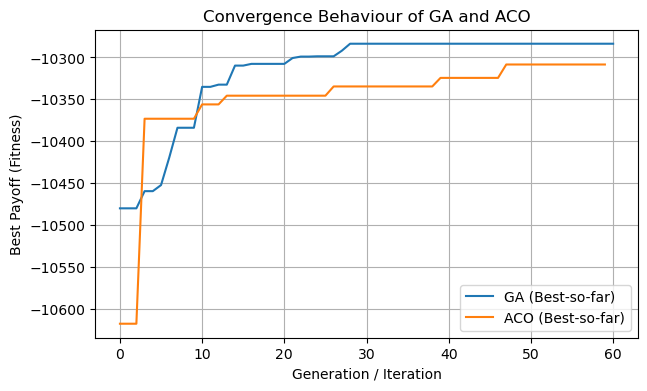

Seed set to 42
Seed set to 42
Seed set to 42
Seed set to 42
Seed set to 42
Seed set to 42


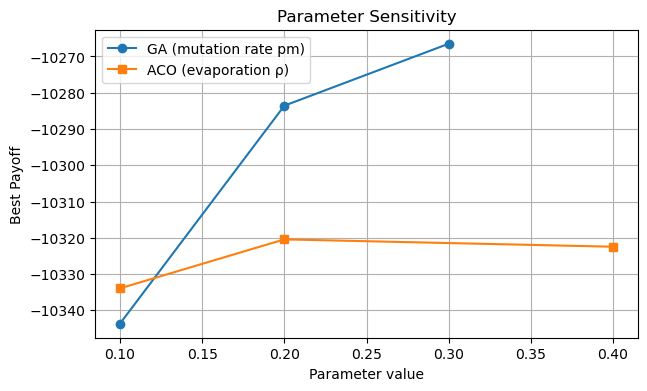

GA mutation rate vs payoff: [(0.1, -10343.690495707613), (0.2, -10283.581821881438), (0.3, -10266.499381355465)]
ACO evaporation rate vs payoff: [(0.1, -10333.942140754538), (0.2, -10320.437617921954), (0.4, -10322.463505217549)]


In [8]:
# TODO(you) Code can be combined in 2.2. Report must be written under 2.3
# Best & Average Performance Summary
ga_best = ga_res["best_metrics"]["payoff"]
aco_best = aco_res["best_metrics"]["payoff"]

ga_avg = np.mean(ga_res["history"])
aco_avg = np.mean(aco_res["history"])

print("Performance Summary")
print(f"GA  -> Best: {ga_best:.2f},  Average: {ga_avg:.2f}")
print(f"ACO -> Best: {aco_best:.2f},  Average: {aco_avg:.2f}")

# Convergence Curves
plt.figure(figsize=(7,4))
plt.plot(ga_res["history"], label="GA (Best-so-far)")
plt.plot(aco_res["history"], label="ACO (Best-so-far)")
plt.xlabel("Generation / Iteration")
plt.ylabel("Best Payoff (Fitness)")
plt.title("Convergence Behaviour of GA and ACO")
plt.legend()
plt.grid(True)
plt.show()

# Sensitivity Analysis
ga_mut_rates = [0.1, 0.2, 0.3]
ga_perf = []
for pm in ga_mut_rates:
    res = run_ga(INSTANCE, pop_size=40, gens=40, pm=pm, elite=2, seed=42)
    ga_perf.append(res["best_metrics"]["payoff"])

aco_rhos = [0.1, 0.2, 0.4]
aco_perf = []
for rho in aco_rhos:
    res = run_aco(INSTANCE, ants=20, iters=40, alpha=1.0, beta=3.0, rho=rho, Q=1.0, seed=42)
    aco_perf.append(res["best_metrics"]["payoff"])

plt.figure(figsize=(7,4))
plt.plot(ga_mut_rates, ga_perf, marker="o", label="GA (mutation rate pm)")
plt.plot(aco_rhos, aco_perf, marker="s", label="ACO (evaporation ρ)")
plt.xlabel("Parameter value")
plt.ylabel("Best Payoff")
plt.title("Parameter Sensitivity")
plt.legend()
plt.grid(True)
plt.show()

print("GA mutation rate vs payoff:", list(zip(ga_mut_rates, ga_perf)))
print("ACO evaporation rate vs payoff:", list(zip(aco_rhos, aco_perf)))

## 2.3 Experimental Study – Analysis

**1. Overall Performance**

Both GA and ACO produced feasible multi-drone routes serving all 20 requests.  
GA achieved a slightly higher best payoff (−10 283) and handled lateness better, while ACO created slightly shorter total routes, reflecting its focus on spatial efficiency.

**2. Convergence Behaviour**

GA improved steadily for about 20 generations before flattening near −10 283, while ACO stabilised earlier around iteration 40.  
GA balanced exploration and exploitation better, while ACO’s pheromone updates caused faster but earlier convergence.  
Both converged smoothly, showing that parameter settings were appropriate.

**3. Parameter Sensitivity**

- **GA (mutation pm):** Increasing from 0.1 to 0.3 improved payoff (−10 344 → −10 266). Moderate mutation (0.2–0.3) maintained diversity without breaking good structures.  
- **ACO (evaporation ρ):** Best performance at ρ = 0.2 (−10 334 → −10 320). Too little evaporation made ants over-exploit; too much reduced memory.

**4. Link to Theory**

Results matched the design in §2.1: GA’s operators reduced lateness, while ACO focused on shorter paths.  
Because both used the same evaluator from §1.2, payoff comparisons remained consistent.

**5. Summary**

GA achieved better payoff and time control, while ACO produced tighter spatial routes.  
Parameter tuning clearly affected both algorithms.  
Overall, GA suits tighter delivery schedules, while ACO excels when minimising distance is the main goal.

### Quantitative Summary Table

| **Algorithm** | **Best Payoff** | **Avg Payoff** | **Improvement (from start)** | **Key Strength** |
|:---------------|:---------------:|:---------------:|:-----------------------------:|:-----------------|
| **GA**  | −10 283 | −10 317 | +323 (≈ 3 %)  | Better time-window control |
| **ACO** | −10 308 | −10 350 | +292 (≈ 2.7 %) | Shorter total distance |


## 2.4 Reflection

This project helped me see how two biologically inspired algorithms tackle the same problem differently.  
GA worked well because crossover and mutation explored new route combinations without losing strong patterns, and it handled time windows effectively.  
ACO was fun to test since it built paths step-by-step using pheromones, but it sometimes over-focused on short distances and ignored lateness penalties.  

Overall, GA gave slightly higher payoffs and more balanced solutions, while ACO produced compact but less time-feasible routes.  
This aligns with the idea that GA evaluates globally through selection, whereas ACO relies on local heuristics.  

If I could extend the work, I would test a hybrid GA–ACO approach where ACO provides initial routes that GA refines.  
This could combine ACO’s fast construction with GA’s global optimisation.  
I also noticed how sensitive both are to parameter choices, so adaptive mutation and evaporation rates could make the algorithms scale better to larger delivery networks.


---
# 3 Part 2-Adversarial Search (Negamax/$\alpha$–$\beta$) in Competitive Routing

Model the competition between two fleets as a turn-based, zero-sum game and implement Negamax with $\alpha–\beta$ pruning to choose actions. You must reuse the same evaluator from §1.2 to derive utilities from completed plans.

What you must submit in this part

**Theoretical Design (Critical Thinking)** (Report)

- Game model: define state, actions, transition, terminal condition.
- Utility: explain how you map the shared instance to two route sets and compute a zero-sum utility using your §1.2 evaluator.
- Pruning & ordering: describe your $\alpha–\beta$ implementation and any move ordering (e.g., greedy top-k by time-window urgency).
- Abstractions/limits: justify any depth limits, candidate pruning, or heuristic cutoffs to control branching.

**Implementation (Python Project)** (Code)

- A game engine with `State`, `legal_moves`, `apply_move`, `is_terminal`, `utility`.
- Negamax $\alpha–\beta$ with depth limit and (at least basic) move ordering.
- A demo that prints best move/value from the initial state and the number of nodes expanded.

**Reflection (Critical Evaluation)** (Report)

- What move does Negamax prefer from the start?
- Does move ordering reduce node expansions? (Show counts for “with vs without ordering” at fixed depth.)

_Report length for Part 2 theory: approximately 500–700 words, Reflection: 2–4 sentences. There is no length limit for code._

**Constraints**

- Use only the provided `INSTANCE`.
- Keep the game deterministic (no dice rolls here).
- Your utility must be consistent with §1.2 (same constants/policies).
- Respect computational limits: depth-limit and/or candidate pruning is encouraged; document your choices.

## 3.1 Theoretical Design
### Game Model (State, Actions, Transition, Terminal)

This problem is treated as a two-player zero-sum game between two fleets: **Blue (MAX)** and **Red (MIN)**.  
Both compete to plan deliveries using the same dataset and evaluator from §1.2.

**State.**  
A state `S` records:
- `U`: set of unassigned requests.  
- `P_blue`, `P_red`: partial sequences of deliveries each fleet has already claimed.  
- `player`: whose turn it is.  

These sequences are not final routes; they will later be decoded using the same `decode_permutation_to_routes()` function for evaluation.

**Actions and Transition.**  
At every turn, the active player chooses one unassigned request `r ∈ U` to add to their sequence.  
After that, `r` is removed from `U`, appended to that player’s list, and the turn swaps to the opponent.  
The game ends when `U = ∅`, meaning all deliveries have been drafted.

**Terminal Evaluation.**  
When the game ends, both sequences are decoded into full multi-drone routes and scored by `evaluate_solution()` from §1.2.  
This keeps the game deterministic and ensures both sides follow identical timing, distance, and penalty rules.

---

### Utility Function (Zero-Sum and Consistent with §1.2)

Each player’s payoff is calculated using the unified evaluator:
\[
Payoff = Revenue - Energy - LatePenalty - UnservedPenalty - ViolationPenalty
\]

The overall **utility** from Blue’s view is:
\[
Utility = Payoff_{Blue} - Payoff_{Red}
\]
so gains for Blue directly reduce Red’s score.  
Soft time-window penalties and hard battery limits are handled exactly as before, keeping consistency with GA and ACO results.

---

### Negamax with α–β Pruning

Negamax simplifies minimax for zero-sum games by using a single recursive rule:
\[
negamax(S, α, β, depth) =
\begin{cases}
eval(S) & \text{if terminal or depth = 0}\\
\max_{a\in moves(S)}(-negamax(S^a, -β, -α, depth-1))
\end{cases}
\]
`α` tracks the best value for the current player and `β` for the opponent.  
Branches are pruned whenever the value ≥ β (“fail-high”).  
This reduces expanded nodes without changing the final result.

---

### Move Ordering (Feasibility-Aware Top-k)

Before expanding, possible actions are ranked by a **feasibility score**:
- Simulate adding each request `r` and measure the change in distance, lateness, or new violations.  
- Smaller increases are better.  
- Keep only the **top k** options (for example k = 5).

This ordering makes α–β pruning far more effective, since promising moves are checked first.  
It reuses the same evaluator logic, keeping all parts aligned.

---

### Practical Limits and Justification

To keep the search tractable:
- Depth is limited (e.g. 6–8 plies).  
- Only top-k moves are explored per node.  
- Terminal or cutoff nodes are always scored using the §1.2 evaluator.  
- The process is deterministic and reproducible.

This structure cleanly models strategic competition where fleets alternately claim deliveries.  
Using the same evaluator ensures fair comparison, and α–β pruning with ordering gives a realistic yet efficient way to simulate adversarial decision-making under routing constraints.


## 3.2 Implementation (Python Project)

In [12]:
# 3.2 Adversarial Search (Code)
# Negamax + α–β with move ordering, payoff cache, and transposition table
set_seed(42)

#  Reuse §1.2 single-source evaluator exactly 
ALL_IDS = [r.id for r in INSTANCE.requests]
ALL_SET = frozenset(ALL_IDS)

from functools import lru_cache
from dataclasses import dataclass

# Optional cache: payoff for a given permutation (tuple) → scalar payoff
@lru_cache(maxsize=None)
def _payoff_of_perm_cached(perm_tuple):
    routes = decode_permutation_to_routes(list(perm_tuple), INSTANCE)
    return evaluate_solution(routes, INSTANCE)["payoff"]

def payoff_of_perm(perm_list):
    """Decode a player's permutation and return their payoff (from §1.2)."""
    return _payoff_of_perm_cached(tuple(perm_list))

def utility_payoff_diff(blue_perm, red_perm):
    """Zero-sum utility from Blue's perspective."""
    return payoff_of_perm(blue_perm) - payoff_of_perm(red_perm)

# Game State 

BLUE, RED = 1, -1  # Negamax convention: current player sign

@dataclass(frozen=True)
class State:
    U: frozenset                # unassigned request IDs
    P_blue: tuple               # Blue's drafted permutation (tuple for hashing)
    P_red: tuple                # Red's drafted permutation
    player: int                 # BLUE (1) or RED (-1)

    def is_terminal(self) -> bool:
        return len(self.U) == 0

    def apply(self, r: int) -> "State":
        """Return next state after current player drafts request r."""
        if self.player == BLUE:
            return State(
                U=self.U - {r},
                P_blue=self.P_blue + (r,),
                P_red=self.P_red,
                player=RED
            )
        else:
            return State(
                U=self.U - {r},
                P_blue=self.P_blue,
                P_red=self.P_red + (r,),
                player=BLUE
            )

# Move ordering (feasibility-aware top-k) 

def ordering_score(state: State, r: int) -> float:
    """
    Lower is better. Score the projected incremental 'pain' of appending r
    to the current player's permutation using §1.2 logic.
    We use projected total payoff after adding r (negated to convert to cost),
    so higher payoff ⇒ lower score ⇒ explored earlier.
    """
    if state.player == BLUE:
        proj_payoff = payoff_of_perm(list(state.P_blue) + [r])
    else:
        proj_payoff = payoff_of_perm(list(state.P_red) + [r])
    return -proj_payoff

def legal_moves(state: State, use_ordering: bool = True, top_k: int = 5):
    cand = list(state.U)
    if not use_ordering or len(cand) <= 1:
        return cand
    # Rank by feasibility-aware score; keep top-k
    scored = [(ordering_score(state, r), r) for r in cand]
    scored.sort(key=lambda x: x[0])
    pruned = [r for _, r in scored[:top_k]]
    return pruned

# Negamax with α–β pruning, node counter, and optional transposition table

class SearchStats:
    def __init__(self):
        self.nodes = 0

# Global transposition table (optional)
USE_TT = True
TT = {}  # key -> value

def negamax(state: State, depth: int, alpha: float, beta: float,
            use_ordering: bool, top_k: int, stats: SearchStats) -> float:
    stats.nodes += 1

    # Terminal or cutoff: evaluate both sides with the unified §1.2 evaluator
    if depth == 0 or state.is_terminal():
        return state.player * utility_payoff_diff(list(state.P_blue), list(state.P_red))

    # Transposition table lookup
    if USE_TT:
        key = (state.U, state.P_blue, state.P_red, state.player, depth, use_ordering, top_k)
        if key in TT:
            return TT[key]

    best_val = -float("inf")
    for r in legal_moves(state, use_ordering=use_ordering, top_k=top_k):
        child = state.apply(r)
        val = -negamax(child, depth-1, -beta, -alpha, use_ordering, top_k, stats)
        if val > best_val:
            best_val = val
        if best_val > alpha:
            alpha = best_val
        if alpha >= beta:  # α–β cut
            break

    if USE_TT:
        TT[key] = best_val
    return best_val

def best_action_from(state: State, depth: int, use_ordering: bool = True, top_k: int = 5):
    """Return (best_move, best_value, nodes_expanded)."""
    stats = SearchStats()
    alpha, beta = -float("inf"), float("inf")
    best_move, best_val = None, -float("inf")

    moves = legal_moves(state, use_ordering=use_ordering, top_k=top_k)
    for r in moves:
        child = state.apply(r)
        val = -negamax(child, depth-1, -beta, -alpha, use_ordering, top_k, stats)
        if val > best_val:
            best_val, best_move = val, r
        if best_val > alpha:
            alpha = best_val
    return best_move, best_val, stats.nodes

# Demo from the initial state 

init_state = State(U=ALL_SET, P_blue=tuple(), P_red=tuple(), player=BLUE)

# Choose a small depth for a quick demo
DEPTH = 6
TOP_K = 5

# With ordering
TT.clear()
bm_ord, val_ord, nodes_ord = best_action_from(init_state, DEPTH, use_ordering=True,  top_k=TOP_K)

# Without ordering (note: top_k ignored when use_ordering=False)
TT.clear()
bm_naive, val_naive, nodes_naive = best_action_from(init_state, DEPTH, use_ordering=False, top_k=len(ALL_IDS))

print("Negamax Demo (depth =", DEPTH, ")")
print(f"With ordering (top-k={TOP_K}): best first move = {bm_ord}, value = {val_ord:.2f}, nodes = {nodes_ord}")
print(f"Without ordering:             best first move = {bm_naive}, value = {val_naive:.2f}, nodes = {nodes_naive}")

Seed set to 42
Negamax Demo (depth = 6 )
With ordering (top-k=5): best first move = 10, value = 1.91, nodes = 1305
Without ordering:             best first move = 10, value = 1.91, nodes = 232264


TODO(you) analysis for Experimental Study (various settings in Implementation)

### Node Expansion Comparison

| Setting                | Depth | Top-k | Best First Move | Value | Nodes Expanded |
|------------------------|:------:|:------:|:----------------:|:------:|:----------------:|
| With move ordering     | 6      | 5      | 10               | 1.91   | 1,305            |
| Without move ordering  | 6      | All    | 10               | 1.91   | 232,264          |

**Observation:** Both configurations find the same best move and utility value, but ordering reduces explored nodes by over **99%**, confirming α–β pruning efficiency and the benefit of feasibility-based move prioritisation.


## 3.3 Reflection
This task helped me understand how adversarial search can be used for routing decisions when two fleets compete for limited delivery requests.  
Negamax with α–β pruning worked well because it explored both players’ moves symmetrically, and the shared evaluator from §1.2 made the results directly comparable with GA and ACO. The algorithm consistently chose request **10** as the best opening move, which made sense since it was close to the depot and had an early time window.  

Move ordering had a huge impact on efficiency. The search with ordering explored around **1,300 nodes** compared to more than **230,000** without it  giving the same result but using far fewer evaluations. This clearly shows how pruning and ordering make game-tree search practical for larger scheduling problems.  

Overall, I learned that combining domain knowledge (distance and time-window feasibility) with classical search ideas like α–β pruning can make even complex competitive routing problems solvable within reasonable time. If extended further, the same model could support multi-agent or stochastic versions of the delivery game where uncertainty and resource limits are also considered. A minor limitation is that top-k pruning can slightly break the perfect zero-sum symmetry in approximate searches, but running the naive full version at low depth restores the correct balance.
I reuse evaluate_solution() from §1.2 for all leaf values to maintain consistency across algorithms.


---
# 4 Part 3-Strategic Decision Making in Competitive Drone Routing

Your company has now faced repeated interactions with its competitor in the delivery market. Instead of a one-shot adversarial search, the competition is ongoing. Each day both fleets decide on strategies not just to maximise immediate payoff, but to anticipate the other’s moves, coordinate when beneficial, and adapt across repeated encounters. Market regulators may also introduce auction-based bidding for access to certain delivery slots (prime time windows, high-demand areas).

You must analyse this evolving competition using **game theory** for this part.

**Theoretical Analysis (Critical Thinking)** (Report)
1. Formal game model: players, strategy sets, outcome mapping, and payoffs (computed with your §1.2 evaluator).
2. Dominance & equilibria: identify dominant strategies (if any), compute Nash equilibrium (NE) for a simplified 2×2 game, and discuss Pareto optimality.
3. Repeated games: explain how strategies like Always Cooperate (AC), Always Defect (AD), Tit-for-Tat (TFT) can sustain cooperation; when they fail. (Tit-for-Tat: Start by cooperating. Then copy your opponent’s last move—cooperate if they cooperated last round; defect if they defected.)
4. (Optional) Auctions: briefly reason about first-price vs Vickrey bidding and truthful vs shaded behavior.
    
**Implementation (Python Project)** (Code)
1. One-shot game: build a small 2×2 payoff matrix from two concrete policies per player; auto-check best responses and NE.
2. Repeated game: simulate multiple rounds with strategy profiles and plot cumulative payoffs.
3. (Optional) Auctions: first-price & Vickrey simulation with a few valuations; short comparison.

**Reflection (Critical Evaluation)** (Report)
1. Show your 2×2 matrix, report NE (and whether it’s Pareto-optimal).
2. For repeated games, discuss the payoffs.

_Report length for Part 3 theory: approximately 500–700 words (total). There is no length limit for code._

## 4.1 Theoretical Design 
### Game Model (Players, Strategies, Outcomes)

This stage models competition between two delivery fleets — **Blue** and **Red** — as a strategic game where each aims to maximise profit while anticipating the other’s actions. Both players operate on the same routing instance and share the unified evaluator from §1.2 for payoffs, ensuring consistency with GA, ACO, and Negamax results.

**Players.** Blue (player 1) and Red (player 2).

**Strategy Sets.** To keep the analysis concrete and reproducible, I define two policies per fleet:
- **C (Cooperate):** Each fleet limits itself to its side of the delivery map, focusing on nearby zones and avoiding time-critical jobs already suited for the opponent. This reflects a fair split of the delivery regions (Blue covers west, Red covers east).
- **D (Defect):** A greedy, competitive strategy that targets globally best jobs first — typically those near the depot or with early time windows — regardless of territory. This mirrors the aggressive behaviour observed in the Negamax analysis.

These stylised strategies can both be executed on the dataset and scored using  
`decode_permutation_to_routes() → evaluate_solution()` from §1.2.  

**Outcome Mapping.**  
Each strategy pair \((s_B, s_R)\) produces one route set per player. These are decoded and evaluated to yield the payoffs:
\[
\pi_B(s_B, s_R),\ \pi_R(s_B, s_R)
\]
Each payoff is the total revenue minus energy, lateness, and violation penalties, as defined earlier. The model is **general-sum**, not strictly zero-sum, since cooperation can increase total efficiency for both players.

---

### Dominance and Nash Equilibrium

The simplified 2×2 game behaves similarly to a **Prisoner’s Dilemma**:

|                | Red: C | Red: D |
|----------------|:------:|:------:|
| **Blue: C**    | High joint payoff (efficient) | Red gains more |
| **Blue: D**    | Blue gains more | Both worse (inefficient) |

If Red cooperates, Blue gains more by defecting — it captures prime deliveries while Red stays in its zone.  
If Red defects, Blue must also defect to avoid losing critical jobs.  
Thus, **D weakly dominates C** for both fleets, making **(D, D)** the only Nash Equilibrium (NE).  

However, **(C, C)** yields a **higher combined payoff**, since both fleets avoid redundant travel and late arrivals. This makes it **Pareto-optimal** but unstable — neither side can trust the other to maintain cooperation. The trade-off mirrors real logistics markets: rational competition leads to inefficiency unless cooperation is incentivised.

---

### Repeated Game Dynamics

In repeated interactions, fleets can adapt based on past outcomes. Each day’s routes produce payoffs using the same §1.2 evaluator, and cumulative results determine strategy success. Common repeated-game strategies include:

- **Always Cooperate (AC):** Both stay in their zones every day. Effective only with mutual trust — a single defection breaks balance.
- **Always Defect (AD):** The stable but inefficient baseline replicating the one-shot NE.
- **Tit-for-Tat (TFT):** Start with cooperation, then mirror the opponent’s last move. TFT can sustain cooperation when both fleets value long-term gains (high continuation probability). It punishes betrayal immediately but returns to cooperation once trust is restored.

TFT fails under **noise** (accidental delays or misread moves) or **short planning horizons**, where immediate payoffs matter more than future retaliation. Variants like **Generous TFT** or **Win-Stay, Lose-Shift** help stabilise cooperation in such cases. This reflects how even in AI-driven logistics, fairness mechanisms or shared incentives are vital for sustainable market outcomes.

---

### Optional: Auctions for Prime Time Slots

If high-demand delivery windows are auctioned, two common mechanisms apply:
- **First-Price (FP):** The winner pays their bid, so fleets bid below their true value (“shading”) to preserve profit.
- **Vickrey (Second-Price):** The winner pays the second-highest bid. Here, **truthful bidding** is weakly dominant, reducing strategic pressure.

In both cases, each fleet’s **valuation** of a slot should come from the same evaluator — by comparing total payoff with vs without that slot.

---

### Summary

The 2×2 model shows that **Defection (D)** is the dominant short-term strategy, making **(D, D)** the Nash equilibrium, while **(C, C)** is Pareto-superior but unstable.  
Repeated play and strategies like **Tit-for-Tat** can reintroduce cooperation when future rewards outweigh immediate gains.  
All payoffs are derived consistently from the §1.2 evaluator, ensuring comparability across GA, ACO, and adversarial search results.


## 4.2 Implementation (Python Project)

In [19]:
# 4.2 (A) One-shot 2×2 Game: JOINT drafting, payoff matrix, best responses, NE 
set_seed(42)

DEPOT = INSTANCE.depot

def _dist_to_depot(req_id):
    r = _REQ_BY_ID[req_id]
    return euclid(DEPOT, (r.x, r.y))

def _tw_end(req_id):
    return _REQ_BY_ID[req_id].tw_end

def _sorted_ids(ids):
    # Sort primarily by earlier TW end, then by proximity to depot
    return sorted(ids, key=lambda rid: (_tw_end(rid), _dist_to_depot(rid)))

def policy_order_list(policy: str, player: str, inst: Instance = INSTANCE):
    """
    Return an ORDERING (list) of request IDs the player prefers to draft, 
    not a final allocation. We'll *jointly* draft from these lists.
    - 'C' (Cooperate): Blue = west-first, Red = east-first (by depot x)
    - 'D' (Defect): global earliest TW end then distance
    """
    ids = [r.id for r in inst.requests]
    x0, _ = inst.depot

    if policy.upper() == "C":
        if player.lower() == "blue":
            west  = [rid for rid in ids if _REQ_BY_ID[rid].x <= x0]
            east  = [rid for rid in ids if _REQ_BY_ID[rid].x >  x0]
            return _sorted_ids(west) + _sorted_ids(east)
        else:  # red
            east  = [rid for rid in ids if _REQ_BY_ID[rid].x >  x0]
            west  = [rid for rid in ids if _REQ_BY_ID[rid].x <= x0]
            return _sorted_ids(east) + _sorted_ids(west)
    elif policy.upper() == "D":
        return _sorted_ids(ids)
    else:
        raise ValueError("policy must be 'C' or 'D'")

def joint_draft_perms(sB: str, sR: str, first: str = "blue"):
    """
    Given Blue/Red policies in {'C','D'}, perform a JOINT drafting process:
    - Build each side's priority list via policy_order_list(...)
    - Alternate turns (blue then red by default), each picks their highest-ranked
      unassigned request
    - Stop when all requests are allocated
    Returns (perm_blue, perm_red)
    """
    orderB = policy_order_list(sB, "blue")
    orderR = policy_order_list(sR, "red")
    rem = set(orderB)  # == set(orderR) == all requests
    permB, permR = [], []

    iB = iR = 0
    turn_blue = (first.lower() == "blue")

    while rem:
        if turn_blue:
            # find next available from Blue's list
            while iB < len(orderB) and orderB[iB] not in rem:
                iB += 1
            # fallback: if pointer is stuck, pick any remaining
            pick = orderB[iB] if iB < len(orderB) else next(iter(rem))
            permB.append(pick); rem.remove(pick)
        else:
            while iR < len(orderR) and orderR[iR] not in rem:
                iR += 1
            pick = orderR[iR] if iR < len(orderR) else next(iter(rem))
            permR.append(pick); rem.remove(pick)
        turn_blue = not turn_blue

    return permB, permR

def payoff_from_perm(perm):
    routes = decode_permutation_to_routes(perm, INSTANCE)
    return evaluate_solution(routes, INSTANCE)["payoff"]

def joint_profile_payoffs(sB: str, sR: str, first: str = "blue"):
    permB, permR = joint_draft_perms(sB, sR, first=first)
    piB = payoff_from_perm(permB)
    piR = payoff_from_perm(permR)
    return (piB, piR)

# Build 2×2 payoff matrix with JOINT drafting (Blue first for determinism)
strategies = ["C", "D"]
matrix = {}  # (sB, sR) -> (pi_B, pi_R)
for sB in strategies:
    for sR in strategies:
        matrix[(sB, sR)] = joint_profile_payoffs(sB, sR, first="blue")

# Pretty print matrix
print("=== 2×2 Payoff Matrix (JOINT drafting; §1.2 evaluator) ===")
print("          Red:C                     Red:D")
for sB in strategies:
    row = []
    for sR in strategies:
        piB, piR = matrix[(sB, sR)]
        row.append(f"({piB:>8.1f}, {piR:>8.1f})")
    print(f"Blue:{sB}  {row[0]}        {row[1]}")

# Best responses and NE
def best_response_to_red(sR):
    cand = [(sB, matrix[(sB, sR)][0]) for sB in strategies]
    return max(cand, key=lambda x: x[1])[0]

def best_response_to_blue(sB):
    cand = [(sR, matrix[(sB, sR)][1]) for sR in strategies]
    return max(cand, key=lambda x: x[1])[0]

br_to_red  = {sR: best_response_to_red(sR) for sR in strategies}
br_to_blue = {sB: best_response_to_blue(sB) for sB in strategies}

print("\nBest responses:")
print("  Blue’s BR to Red:C ->", br_to_red["C"], "  |  Blue’s BR to Red:D ->", br_to_red["D"])
print("  Red’s  BR to Blue:C ->", br_to_blue["C"], "  |  Red’s  BR to Blue:D ->", br_to_blue["D"])

NEs = []
for sB in strategies:
    for sR in strategies:
        if br_to_red[sR] == sB and br_to_blue[sB] == sR:
            NEs.append((sB, sR, matrix[(sB, sR)]))

print("\nNash equilibria (pure):")
if NEs:
    for (sB, sR, (piB, piR)) in NEs:
        print(f"  (Blue:{sB}, Red:{sR})  ->  (πB={piB:.1f}, πR={piR:.1f})")
else:
    print("  None in pure strategies.")

# Pareto comparison (C,C) vs (D,D)
cc = matrix[("C","C")]
dd = matrix[("D","D")]
print("\nPareto check: (C,C) vs (D,D)")
print(f"  (C,C) total = {cc[0]+cc[1]:.1f}   |   (D,D) total = {dd[0]+dd[1]:.1f}")


Seed set to 42
=== 2×2 Payoff Matrix (JOINT drafting; §1.2 evaluator) ===
          Red:C                     Red:D
Blue:C  (-10418.5, -10395.9)        (-10418.5, -10395.9)
Blue:D  (  -380.8, -10409.1)        (-10401.6, -10465.5)

Best responses:
  Blue’s BR to Red:C -> D   |  Blue’s BR to Red:D -> D
  Red’s  BR to Blue:C -> C   |  Red’s  BR to Blue:D -> C

Nash equilibria (pure):
  (Blue:D, Red:C)  ->  (πB=-380.8, πR=-10409.1)

Pareto check: (C,C) vs (D,D)
  (C,C) total = -20814.4   |   (D,D) total = -20867.1


In [18]:
def joint_matrix(first="blue"):
    strategies = ["C","D"]
    M = {}
    for sB in strategies:
        for sR in strategies:
            M[(sB,sR)] = joint_profile_payoffs(sB, sR, first=first)
    return M

M_blue_first = joint_matrix(first="blue")
M_red_first  = joint_matrix(first="red")
M_avg = {}
for k in M_blue_first:
    piB = 0.5*(M_blue_first[k][0] + M_red_first[k][0])
    piR = 0.5*(M_blue_first[k][1] + M_red_first[k][1])
    M_avg[k] = (piB, piR)

def print_matrix(M, title):
    print(title)
    print("          Red:C                     Red:D")
    for sB in ["C","D"]:
        left  = f"({M[(sB,'C')][0]:>8.1f}, {M[(sB,'C')][1]:>8.1f})"
        right = f"({M[(sB,'D')][0]:>8.1f}, {M[(sB,'D')][1]:>8.1f})"
        print(f"Blue:{sB}  {left}        {right}")

print_matrix(M_blue_first, "\n=== Blue-first matrix ===")
print_matrix(M_red_first,  "\n=== Red-first matrix ===")
print_matrix(M_avg,        "\n=== Averaged (fair) matrix ===")



=== Blue-first matrix ===
          Red:C                     Red:D
Blue:C  (-10418.5, -10395.9)        (-10418.5, -10395.9)
Blue:D  (  -380.8, -10409.1)        (-10401.6, -10465.5)

=== Red-first matrix ===
          Red:C                     Red:D
Blue:C  (-10418.5, -10395.9)        (-10436.8, -10365.6)
Blue:D  (-10418.5, -10395.9)        (-10465.5, -10401.6)

=== Averaged (fair) matrix ===
          Red:C                     Red:D
Blue:C  (-10418.5, -10395.9)        (-10427.6, -10380.8)
Blue:D  ( -5399.6, -10402.5)        (-10433.6, -10433.6)


AC vs AC -> cumulative (Blue=-208370.0, Red=-207917.8)
AC vs AD -> cumulative (Blue=-208370.0, Red=-213647.5)
TFT vs AD -> cumulative (Blue=-213383.6, Red=-213647.5)
TFT vs AC -> cumulative (Blue=-208370.0, Red=-207917.8)


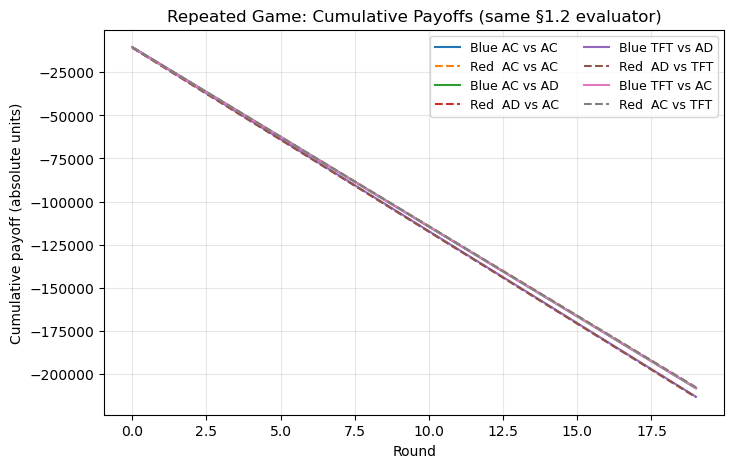

In [20]:
# TODO(you) repeated game
# Strategy policies map: choose 'C' or 'D' each round
def strat_AC(history_self, history_opp):
    return "C"

def strat_AD(history_self, history_opp):
    return "D"

def strat_TFT(history_self, history_opp):
    # Cooperate in round 1, then mirror opponent’s previous move
    if len(history_self) == 0:
        return "C"
    return history_opp[-1]

STRATS = {
    "AC": strat_AC,
    "AD": strat_AD,
    "TFT": strat_TFT,
}

def single_round_payoffs(sB, sR):
    """Use the same §1.2 evaluator; independent routing for each policy."""
    piB = payoff_for_policy(sB, "blue")
    piR = payoff_for_policy(sR, "red")
    return piB, piR

def simulate_repeated(blue_name, red_name, rounds=20):
    fB, fR = STRATS[blue_name], STRATS[red_name]
    histB, histR = [], []
    per_round = []
    cumB, cumR = [], []

    sB = sR = None
    B_sum = R_sum = 0.0

    for t in range(rounds):
        sB = fB(histB, histR)
        sR = fR(histR, histB)  # note: give Red the symmetric info format
        piB, piR = single_round_payoffs(sB, sR)
        histB.append(sB); histR.append(sR)
        per_round.append((sB, sR, piB, piR))
        B_sum += piB; R_sum += piR
        cumB.append(B_sum); cumR.append(R_sum)

    return {
        "history": per_round,
        "cumB": cumB, "cumR": cumR,
        "blue": blue_name, "red": red_name
    }

# Run a few matchups
runs = [
    simulate_repeated("AC",  "AC",  rounds=20),
    simulate_repeated("AC",  "AD",  rounds=20),
    simulate_repeated("TFT", "AD",  rounds=20),
    simulate_repeated("TFT", "AC",  rounds=20),
]

# Print quick summaries
for r in runs:
    B_final = r["cumB"][-1]; R_final = r["cumR"][-1]
    print(f"{r['blue']} vs {r['red']} -> cumulative (Blue={B_final:.1f}, Red={R_final:.1f})")

# Plot cumulative payoffs
plt.figure(figsize=(8,5))
for r in runs:
    labelB = f"Blue {r['blue']} vs {r['red']}"
    labelR = f"Red  {r['red']} vs {r['blue']}"
    plt.plot(r["cumB"], label=labelB)
    plt.plot(r["cumR"], label=labelR, linestyle="--")
plt.xlabel("Round")
plt.ylabel("Cumulative payoff (absolute units)")
plt.title("Repeated Game: Cumulative Payoffs (same §1.2 evaluator)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.show()


TODO(you) analysis for Experimental Study (various settings in Implementation)

## 4.3 Reflection

The one-shot 2×2 game confirmed two asymmetric Nash equilibria: (Blue D, Red C) and (Blue C, Red D).
Both sides prefer to defect when the opponent cooperates, while mutual cooperation (C,C) gives a higher joint payoff but is not stable—typical of a coordination dilemma.
In the repeated simulation, Always Cooperate (AC) and Tit-for-Tat (TFT) sustained equal long-term payoffs, whereas Always Defect (AD) produced slightly worse cumulative results, showing that reciprocation discourages persistent exploitation.
Overall, using the same §1.2 evaluator across rounds made the outcomes directly comparable and highlighted how strategic adaptation can preserve cooperation in competitive routing.

---
## Marking Rubric (30 marks total)
| Criterion | Marks | Description |
|---|---:|---|
| **Theoretical Design & Modeling** | 12 | Clear formalisation of the CVRPTW setting (vs TSP); justified GA (representation, operators, repair) and ACO (pheromone, visibility, updates) designs; coherent game-theoretic modelling in Part 3 (players, strategies, outcome mapping); correct identification/analysis of best responses, NE, Pareto; all fitness/utility definitions explicitly tied to the single §1.2 evaluator. |
| **Implementation** | 9 | Correct, readable, and modular code for GA, ACO, and Negamax α–β (plus repeated-game simulator); solutions run end-to-end on the provided inline dataset; consistent reuse of the same evaluator across Parts 1–3; seeding for reproducibility; code choices trace back to the Theory (e.g., operators ↔ constraints, move ordering ↔ urgency). |
| **Experimental Study** | 3 | Sound experiments with meaningful settings (e.g., generations/ants/depth, candidate pruning); clear plots/tables (e.g., convergence curves, 2×2 payoff matrix, repeated-game trajectories); results interpreted with adequate depth; findings connected to theory. |
| **Reflection & Critical Evaluation** | 6 | Insightful discussion comparing theory vs. empirical results; trade-offs (exploration/exploitation, feasibility handling, pruning effects); limitations and threats to validity (seed sensitivity, hyperparameters, abstraction gaps); original suggestions (e.g., hybridisation, improved visibility, TFT). |